<a href="https://colab.research.google.com/github/Alvaro-Javier-Cavadia/Project_Entity_Recognition_for_Optimization/blob/main/Entity_Recognition_for_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='056938'> **Description** </font>

# <font color='056938'> **Environment setup** </font>

## <font color='8EC044'> **Install packages and libraries** </font>

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia
!pip install langchain_tavily

In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from typing import Annotated, List, TypedDict
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from IPython.display import Image, display

## <font color='8EC044'> **Define API_KEYS** </font>



In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# <font color='056938'> **Create graph resources** </font>

## <font color='8EC044'> **Get acces to the `LLM`** </font>

In this notebook we will use `ChatGPT` from OPENAI

In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

## <font color='8EC044'> **Define Schemas** </font>

Output schemas

In [ ]:
class OneSet(BaseModel):
  name: str = Field(description="Name of the set.")
  description: str = Field(description="Description of the set.")

class Sets(BaseModel):
  sets: List[OneSet] = Field(description="Comprehensive list of sets.")

class Param(BaseModel):
  name: str = Field(description="Name of the parameter.")
  description: str = Field(description="Description of the parameter.")
  indexes: List[OneSet] = Field(description="List of sets in which the parameter is indexed.")

class Parameters(BaseModel):
  parameters: List[Param] = Field(description="Comprehensive list of parameters.")

class Decision(BaseModel):
  name: str = Field(description="Name of the decision.")
  description: str = Field(description="Description of the decision.")
  indexes: List[OneSet] = Field(description="List of sets in which the decision is indexed.")
  decision_type: str = Field(description="Type of the decision. (It can be integer, continuous, or binary)")

class Decisions(BaseModel):
  decisions: List[Decision] = Field(description="Comprehensive list of decisions.")



State schema

In [ ]:
from operator import add
from typing import Annotated


class GeneralState(TypedDict):
  problem: str # Problem description
  human_feedback_sets: Annotated[list[str], add] # Human feedback
  human_feedback_params: Annotated[list[str], add] # Human feedback
  human_feedback_decision: Annotated[list[str], add] # Human feedback
  sets: List[OneSet] # Generated sets
  parameters: List[Param] # Generated parameters
  decisions: List[Decision] # Generated decision

## <font color='8EC044'> **Define prompts** </font>

Two prompts are considered for each of the main nodes to be considered



### <font color='008CD2'> **Prompt for set extraction** </font>

This prompt instructs the model to extract and refine the relevant mathematical optimization sets needed to formulate the problem. It takes as arguments:
* `problem`: The description fo the problem
* `pre_sets`: The sets identified in a previous attempt, used to validate and avoid duplication when refining the output after feedback is provided.
* `human_feedback_sets`: Optional feedback from a human analyst used to correct, refine, or complete the extracted sets.

In [ ]:
prompt_sets_extraction = """
You are an expert in mathematical optimization modeling. Your task is to identify the sets required to formulate the given optimization problem.

A *set* is a collection of items (e.g., products, customers, time periods, locations, machines, vehicles) used to define indices over which parameters, decision variables, and constraints are structured.

Follow these steps carefully:

1. Read the problem description:
{problem}

2. If a previous attempt has been made to define here is the result to validate
they are included but not duplicated in the new answer. Otherwise, ignore this information:
{pre_sets}

3. Review the optional human analyst feedback (if provided). Use it to refine, correct, or complete the sets:
{human_feedback_sets}

4. Extract all relevant sets needed for modeling the problem.

Guidelines:
- Only include sets that are meaningful for defining indices in the model.
- Each set must represent a distinct category of entities (e.g., products, suppliers, time periods).
- Avoid listing parameters or variables as sets unless they truly represent a collection of entities.

- Use clear, concise set names.

"""

### <font color='008CD2'> **Prompt for parameters extraction** </font>

This prompt instructs the model to extract the parameters needed to formulate the problem. It takes as arguments:

* `sets`: The sets identified in the previous node, used to define the indices of the parameters.
* `human_feedback_params`: Optional feedback from a human analyst used to correct, refine, or complete the extracted parameters.
* `pre_params`: The params identified in a previous attempt, used to validate and avoid duplication when refining the output after feedback is provided.

In [ ]:
prompt_params_extraction = """
You are an expert in mathematical optimization modeling. Your task is to identify the parameters required to formulate the given optimization problem.

A *parameter* in an optimization model is a fixed input value (known data) that influences the model but is not a decision variable and therefore does
not change during the optimization process. If a parameter is not indexed, then it is associated with a single scalar value. If a parameter is indexed
over one or more sets, then each combination of indices corresponds to a different value of that parameter.


Follow these steps carefully:

1. Consider the problem description that has been provided previously.

2. If a previous attempt has been made to define the parameters here is the result to validate
they are included but not duplicated in the new answer. Otherwise, ignore this information:
{pre_params}

3. Review the optional human analyst feedback (if provided). Use it to refine, correct, or complete the parameters:
{human_feedback_params}

4. Extract all relevant parameters needed for modeling the problem.

5. Identify the sets over which these parameters are indexed, if any. Consider the following sets:
{sets}

Guidelines:
- Use clear, concise parameters names.


"""

### <font color='008CD2'> **Prompt for decisions extraction** </font>

This instruction tells the model to extract the decision variables needed to formulate the problem. It takes the following arguments:

- `sets`: The sets identified in the previous node, used to define the indices of the decision variables.
- `human_feedback_decision`: Optional feedback from a human analyst used to correct, refine, or complete the extracted decision variables.
- `pre_decisions`: The decision variables identified in a previous attempt, used to validate and avoid duplication when refining the result after providing feedback.

In [ ]:
prompt_decision_extraction = """You are an expert in mathematical optimization modeling. Your task is to identify the decision variables needed to formulate the given optimization problem.

A *decision variable* in an optimization model consists of the unknown quantities that are adjusted to achieve the model's optimal solution. They represent the decisions that must be made, such as the quantity of product to produce or the amount of resources to allocate. They are indexed to one or more sets since these are the sets upon which the decisions are based.

Follow these steps carefully:

1. Consider the problem description provided previously.

2. If you attempted to define the decision variables previously, this is the result to validate that they should be included, but not duplicated, in the new answer. Otherwise, ignore this information:

{pre_decisions}

3. Review the optional feedback from the human analyst (if provided). Use it to refine, correct, or complete the parameters:

{human_feedback_decision}

4. Extract all the decision variables necessary to model the problem.

5. Identify the sets on which these decision variables are indexed, if any. Consider the following sets:

{sets}

Instructions:
- Use clear and concise decision variable names."""

## <font color='8EC044'> **Define auxiliary functions** </font>

The `print_event` function is an auxiliary function designed to display the contents of the `sets` and `parameters` within an `event` state. It iterates through lists of `OneSet` and `Param` objects, printing their names, descriptions, and indexes (for parameters) in a formatted way.

In [ ]:
def print_event(event):
  """Prints the details of sets and parameters from an event state."""
  # Get the list of sets from the event state, defaulting to an empty list if not found
  sets = event.get("sets", [])
  # Iterate through each set and print its name and description
  if sets:
    print("---------- SETS -------------")
    for one_set in sets:
        print(f"Name: {one_set.name}")
        print(f"description: {one_set.description}")
        print("-" * 50)

  # Get the list of parameters from the event state, defaulting to an empty list if not found
  params = event.get("parameters", [])
  # Iterate through each parameter and print its name, description, and indexes
  if params:
    print("---------- PARAMETERS -------------")
    for param in params:
        print(f"Name: {param.name}")
        print(f"description: {param.description}")
        print(f"indexes: {param.indexes}")
        print("-" * 50)

  decisions = event.get("decisions", [])

  if decisions:
    print("---------- DECISION VARIABLES -------------")
    for decision_v in decisions:
        print(f"Name: {decision_v.name}")
        print(f"description: {decision_v.description}")
        print(f"indexes: {decision_v.indexes}")
        print(f"decision_type: {decision_v.decision_type}")
        print("-" * 50)






# <font color='056938'> **Graph: Human in the loop Agent** </font>

Human-in-the-loop (HITL) leverages both human and machine intelligence to create robust and accurate models. The human provides feedback at critical junctures in the machine learning workflow, enhancing the model's performance and ensuring ethical and accurate outcomes.

## <font color='8EC044'> **Create the nodes functions** </font>

The `human_feedback_sets` and `conditional_for_sets` functions complement `identify_sets` to create a human-in-the-loop mechanism for refining the identified sets.

*   **`identify_sets`**: This function is responsible for the initial identification of sets based on the problem description and any previous feedback.
*   **`human_feedback_sets`**: This is a no-op (no operation) node in the graph. Its purpose is to act as an interruption point. When the graph reaches this node, execution pauses, allowing a human analyst to review the `sets` identified by `identify_sets`.
*   **`conditional_for_sets`**: After the human feedback node, this conditional function checks if any new feedback has been provided by the human analyst. If `human_feedback_sets` contains new information, the graph is re-routed back to `identify_sets` to refine the sets based on the new input. If no feedback is given (i.e., the human is satisfied), the graph proceeds to the next stage (`identify_params`).

This loop ensures that the set identification process can be iteratively improved with expert human input until a satisfactory result is achieved.

In [ ]:
def identify_sets(state: GeneralState):

    """ identify sets """
    problem=state['problem']
    pre_sets=state.get('sets', '')

    human_feedback_sets=state.get('human_feedback_sets', '')

    # Enforce structured output
    structured_llm = llm.with_structured_output(Sets)

    # System message
    system_message = prompt_sets_extraction.format(problem=problem,
                                                   pre_sets=pre_sets,
                                                   human_feedback_sets=human_feedback_sets,
                                                )

    # Generate question
    sets = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Identify the sets in the problem description.")])

    # Write the set to state
    return  {"sets": sets.sets}

def human_feedback_sets(state: GeneralState):
    """ No-op node that should be interrupted on """
    pass

def conditional_for_sets(state: GeneralState):
    """ Return the next node to execute """

    # Check if human feedback
    human_feedback_sets=state.get('human_feedback_sets', None)

    if human_feedback_sets[-1] != None:
        return "identify_sets"

    # Otherwise end
    return "identify_params"

Similarly, we do the same for the identification of the parameters

In [ ]:
def identify_params(state: GeneralState):

    """ identify parameters """
    problem=state['problem']
    sets=state.get('sets', '')
    pre_params=state.get('parameters', '')

    human_feedback_params=state.get('human_feedback_params', '')

    # Enforce structured output
    structured_llm = llm.with_structured_output(Parameters)


    # System message
    system_message = prompt_params_extraction.format(problem=problem,
                                                   pre_params=pre_params,
                                                   sets=sets,
                                                   human_feedback_params=human_feedback_params,
                                                )

    # Generate question
    parameters = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Identify the parameters in the problem description.")])

    # Write the set to state
    return  {"parameters": parameters.parameters}

def human_feedback_params(state: GeneralState):
    """ No-op node that should be interrupted on """
    pass

def conditional_for_params(state: GeneralState):
    """ Return the next node to execute """

    # Check if human feedback
    human_feedback_params=state.get('human_feedback_params', None)

    if human_feedback_params[-1] != None:
        return "identify_params"

    # Otherwise end
    return "identify_decisions"

Nodes to identify decision variables and their feedback


In [ ]:
def identify_decisions(state: GeneralState):

    """ identify decisions """
    problem=state['problem']
    sets=state.get('sets', '')
    pre_decisions=state.get('decisions', '')
    human_feedback_decision=state.get('human_feedback_decision', '')

    # Enforce structured output
    structured_llm = llm.with_structured_output(Decisions)


    # System message
    system_message = prompt_decision_extraction.format(problem=problem,
                                                   pre_decisions=pre_decisions,
                                                   sets=sets,
                                                   human_feedback_decision=human_feedback_decision,
                                                )

    # Generate question
    decision = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Identify the decision variables in the problem description.")])

    # Write the set to state
    return  {"decisions": decision.decisions}

def human_feedback_decision(state: GeneralState):
    """ No-op node that should be interrupted on """
    pass

def conditional_for_decision(state: GeneralState):
    """ Return the next node to execute """

    # Check if human feedback
    human_feedback_decision=state.get('human_feedback_decision', None)

    if human_feedback_decision[-1] != None:
        return "identify_decisions"

    # Otherwise end
    return END

## <font color='8EC044'> **Create the graph** </font>

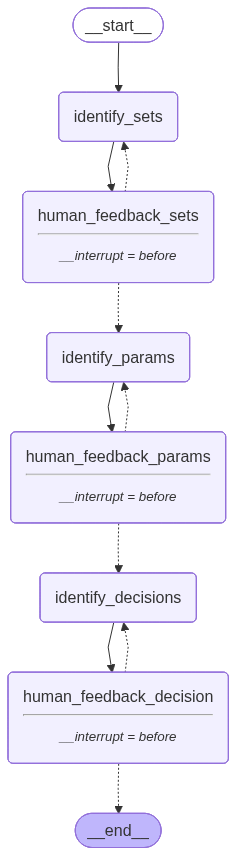

In [ ]:
# Add nodes and edges
builder = StateGraph(GeneralState)
builder.add_node("identify_sets", identify_sets)
builder.add_node("human_feedback_sets", human_feedback_sets)
builder.add_node("identify_params", identify_params)
builder.add_node("human_feedback_params", human_feedback_params)
builder.add_node("identify_decisions", identify_decisions)
builder.add_node("human_feedback_decision", human_feedback_decision)

builder.add_edge(START, "identify_sets")
builder.add_edge("identify_sets", "human_feedback_sets")
builder.add_conditional_edges("human_feedback_sets", conditional_for_sets, ["identify_sets", "identify_params"])
builder.add_edge("identify_params", "human_feedback_params")
builder.add_conditional_edges("human_feedback_params", conditional_for_params, ["identify_params", "identify_decisions"])
builder.add_edge("identify_decisions", "human_feedback_decision")
builder.add_conditional_edges("human_feedback_decision", conditional_for_decision, ["identify_decisions", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback_sets', 'human_feedback_params', "human_feedback_decision"], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

## <font color='8EC044'> **Run some tests** </font>

Multiple optimization problems are selected to evaluate the performance of the artificial intelligence agent, each with different levels of difficulty.

In [ ]:
problem1 = """A company in the south-west of France needs to transport 180 tonnes
of chemical products stored in depots D1 to D4 to the three recycling centers C1,
C2, and C3. The ammount of chemical products in each depot is known. Two modes of
transport are available: road and rail. Depot D1 only delivers to centers C1 and
C2 and that by road. Depot D2 only delivers to C2, by rail or road. Depot D3
delivers to center C2 by road and to C3 by rail or road. The depot D4 delivers to
center C2 and C3 by rail or road. Its contract with the railway company for the
transport of chemical products requires the ammount to transport in any single
delivery to be between a certain lower and upper limit. Besides the standard
security regulations, there are no specific limitations that apply to road transport.
How should the company transport the chemicals from depots to centers to minimize
the total cost of transport?"""

problem2 = """There is a water transport network. The nodes represent the cities,
the reservoirs, and the pumping stations connected by a network of pipes.
The three cities Gotham City, Metropolis, and Spider Ville are supplied from two
reservoirs. The availabilities of water from these reservoirs in thousands
of m3/h are known. The capacity of each pipe connection is indicated in thousands
of m3/h. The demands of the cities in ten years time are also given. Determine
the maximum flow in the current network"""

problem3 = """A country in Southeast Asia is experiencing widespread flooding.
The government, with international help, decides to establish a system of supply
by air. Unfortunately, only seven runways are still in a usable state, among
which is the one in the capital. The government decides to have the planes leave
from the capital, visit all the other six airports, and then return to the capital.
The  distances between the airports is given.  In which order should the airports
be visited to minimize the total distance covered?"""

problem4 = """A small car rental company has a fleet of vehicles distributed among
its agencies. The location of each agency is known and the distances between agencies
are given in kilometers. The number of cars needed the next morning and the stock of
cars from the evening before this day at each gency are also known. Assuming that the
cost of transporting a car per km is known, determine the car movements that will allow
the company to restore the number of cars needed at all agencies, minimizing the total
cost incurred for transportation."""

### <font color='008CD2'> **Automatize the feedback** </font>

We add a `while` loop for providing feedback that operates as follows:

1.  **Collect Feedback**: It prompts the user to enter feedback for the current stage (sets or parameters). If the user enters an empty string, the feedback is considered `None`, indicating satisfaction or no further changes.
2.  **Update State**: The collected feedback is then used to update the graph's state using `graph.update_state()`. The `as_node` argument specifies which node the feedback is coming from (`human_feedback_sets` or `human_feedback_params`).
3.  **Rerun Graph**: After updating the state, the graph is restarted from the current point (`graph.stream(None, thread, stream_mode="values")`). Because the graph was compiled with `interrupt_before`, it will run until the next `human_feedback_sets` or `human_feedback_params` node, allowing the LLM to process the new feedback and refine its output.
4.  **Display Output**: The output of the refined step is then printed using `print_event()`.
5.  **Loop Continuation**: This process repeats until the user provides `None` as feedback, at which point the loop terminates, and the graph either moves to the next stage (e.g., from sets to parameters) or finishes execution.

Assign the selected problem to a `problem`, to avoid manually modifying the problem in each different execution.

In [ ]:
problem = problem2

In [ ]:
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream({"problem":problem,}, thread, stream_mode="values"):
    # Review
    print_event(event)

# We now update the state as if we are the human_feedback node
print("--------ADD SET FEEDBACK-----------")
feedback = "message"
while feedback != None:
  feedback = input("Enter your feedback or press Enter to leave empty): ").strip()
  feedback = feedback if feedback != "" else None
  print('feedback:', feedback)
  graph.update_state(thread,
                     {"human_feedback_sets":[feedback]},
                     as_node="human_feedback_sets")

  # Restart the graph until the first interruption
  final_event = None

  for event in graph.stream(None, thread, stream_mode="values"):
      final_event = event   # keep overwriting until the end

  print_event(final_event)

print("--------ADD PARAMETERS FEEDBACK-----------")
feedback = "message"
while feedback != None:
  feedback = input("Enter your feedback or press Enter to leave empty): ").strip()
  feedback = feedback if feedback != "" else None
  print('feedback:', feedback)
  graph.update_state(thread,
                     {"human_feedback_params":[feedback]},
                     as_node="human_feedback_params")

  # Restart the graph until the first interruption
  final_event = None

  for event in graph.stream(None, thread, stream_mode="values"):
      final_event = event   # keep overwriting until the end

  print_event(final_event)


print("--------ADD DECISION VARIABLE FEEDBACK-----------")
feedback = "message"
while feedback != None:
  feedback = input("Enter your feedback or press Enter to leave empty): ").strip()
  feedback = feedback if feedback != "" else None
  print('feedback:', feedback)
  graph.update_state(thread,
                     {"human_feedback_decision":[feedback]},
                     as_node="human_feedback_decision")

  # Restart the graph until the first interruption
  final_event = None

  for event in graph.stream(None, thread, stream_mode="values"):
      final_event = event   # keep overwriting until the end

  print_event(final_event)